# Gemini 3.1 Analysis by Length

Gemini 3.1 Pro only, highest-example runs only, raw MathML length only.


## Notebook setup

In [1]:
from pathlib import Path
import re

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

RESULT_DIR = Path("../results/gemini")

from analysis_utils import count_braille_chars, parse_result_file


In [2]:
RESULT_SPECS = [
    {
        "case": "MathML -> Nemeth",
        "direction": "mathml_to_braille",
        "braille_code": "nemeth",
        "path": RESULT_DIR / "to-nemeth-gemini-3.1-pro-preview-2471exs-0-200tests.txt",
        "use_normalized": False,
    },
    {
        "case": "Braille -> Nemeth MathML",
        "direction": "braille_to_mathml",
        "braille_code": "nemeth",
        "path": RESULT_DIR / "from-nemeth-gemini-3.1-pro-preview-2471exs-0-200tests.txt",
        "use_normalized": True,
    },
    {
        "case": "MathML -> UEB",
        "direction": "mathml_to_braille",
        "braille_code": "ueb",
        "path": RESULT_DIR / "to-ueb-gemini-3.1-pro-preview-2351exs-0-200tests.txt",
        "use_normalized": False,
    },
    {
        "case": "Braille -> UEB MathML",
        "direction": "braille_to_mathml",
        "braille_code": "ueb",
        "path": RESULT_DIR / "from-ueb-gemini-3.1-pro-preview-2351exs-0-200tests.txt",
        "use_normalized": True,
    },
]

QUINTILE_LABELS = ["0-20%", "20-40%", "40-60%", "60-80%", "80-100%"]


def footer_matches(path: Path) -> tuple[int, int]:
    # finds the footer line like "# Matches: 183 out of 200: 92%" for sanity checks
    text = path.read_text(encoding="utf-8")
    correct, total = re.findall(r"# Matches: (\d+) out of (\d+):", text)[-1]
    return int(correct), int(total)


rows = []
for spec in RESULT_SPECS:
    parsed = parse_result_file(str(spec["path"]), use_normalized=spec["use_normalized"])
    footer_correct, footer_total = footer_matches(spec["path"])
    assert len(parsed) == footer_total == 200
    assert sum(r.is_correct for r in parsed) == footer_correct

    if spec["direction"] == "mathml_to_braille":
        mathml_field = "input_text"
        braille_field = "expected"
    else:
        mathml_field = "expected"
        braille_field = "input_text"

    for result in parsed:
        rows.append(
            {
                "case": spec["case"],
                "direction": spec["direction"],
                "braille_code": spec["braille_code"],
                "is_success": result.is_correct,
                "mathml_length": len(getattr(result, mathml_field)),
                "braille_length": count_braille_chars(getattr(result, braille_field)),
            }
        )

df = pd.DataFrame(rows)
df["length_bin"] = (
    df.groupby("case", group_keys=False)["mathml_length"]
    .apply(lambda s: pd.qcut(s, q=5, labels=QUINTILE_LABELS, duplicates="drop"))
)


## Overall Results


In [3]:
overall_summary = (
    df.groupby(["case", "direction", "braille_code"], as_index=False)
    .agg(
        total=("is_success", "size"),
        correct=("is_success", "sum"),
        success_rate=("is_success", "mean"),
        min_mathml_length=("mathml_length", "min"),
        median_mathml_length=("mathml_length", "median"),
        max_mathml_length=("mathml_length", "max"),
    )
)
display(overall_summary)


,case,direction,braille_code,total,correct,success_rate,min_mathml_length,median_mathml_length,max_mathml_length
0,Braille -> Nemeth MathML,braille_to_mathml,nemeth,200,183,0.915,25,99.0,535
1,Braille -> UEB MathML,braille_to_mathml,ueb,200,172,0.860,25,99.0,535
2,MathML -> Nemeth,mathml_to_braille,nemeth,200,183,0.915,23,108.5,537
3,MathML -> UEB,mathml_to_braille,ueb,200,160,0.800,23,108.5,537


## Success Rate by MathML Length Quintile


In [4]:
quintile_summary = (
    df.groupby(["case", "length_bin"], observed=True, as_index=False)
    .agg(
        total=("is_success", "size"),
        correct=("is_success", "sum"),
        success_rate=("is_success", "mean"),
        min_mathml_length=("mathml_length", "min"),
        median_mathml_length=("mathml_length", "median"),
        max_mathml_length=("mathml_length", "max"),
    )
)
quintile_summary["success_rate_pct"] = (quintile_summary["success_rate"] * 100).round(2)
length_bin_labels = (
    quintile_summary.groupby("length_bin", observed=True)["median_mathml_length"]
    .agg(["min", "max"])
    .reindex(QUINTILE_LABELS)
)
length_bin_labels["label"] = length_bin_labels.apply(
    lambda row: f"{row.name}\nmedian {int(row['min'])}-{int(row['max'])}" if row['min'] != row['max'] else f"{row.name}\nmedian {int(row['min'])}",
    axis=1,
)
display(quintile_summary.sort_values(["case", "length_bin"]))


,case,length_bin,total,correct,success_rate,min_mathml_length,median_mathml_length,max_mathml_length,success_rate_pct
0,Braille -> Nemeth MathML,0-20%,46,44,0.956522,25,27.0,51,95.65
1,Braille -> Nemeth MathML,20-40%,36,33,0.916667,52,55.0,79,91.67
2,Braille -> Nemeth MathML,40-60%,39,39,1.000000,81,101.0,140,100.00
3,Braille -> Nemeth MathML,60-80%,41,34,0.829268,141,170.0,225,82.93
4,Braille -> Nemeth MathML,80-100%,38,33,0.868421,227,284.0,535,86.84
5,Braille -> UEB MathML,0-20%,46,43,0.934783,25,27.0,51,93.48
6,Braille -> UEB MathML,20-40%,36,30,0.833333,52,55.0,79,83.33
7,Braille -> UEB MathML,40-60%,39,35,0.897436,81,101.0,140,89.74
8,Braille -> UEB MathML,60-80%,41,36,0.878049,141,170.0,225,87.80
9,Braille -> UEB MathML,80-100%,38,28,0.736842,227,284.0,535,73.68


In [5]:
display(quintile_summary.pivot(index="case", columns="length_bin", values="success_rate_pct"))

length_bin,0-20%,20-40%,40-60%,60-80%,80-100%
case,,,,,
Braille -> Nemeth MathML,95.65,91.67,100.00,82.93,86.84
Braille -> UEB MathML,93.48,83.33,89.74,87.80,73.68
MathML -> Nemeth,97.56,100.00,94.87,87.18,77.50
MathML -> UEB,95.12,95.12,84.62,71.79,52.50


## Plot


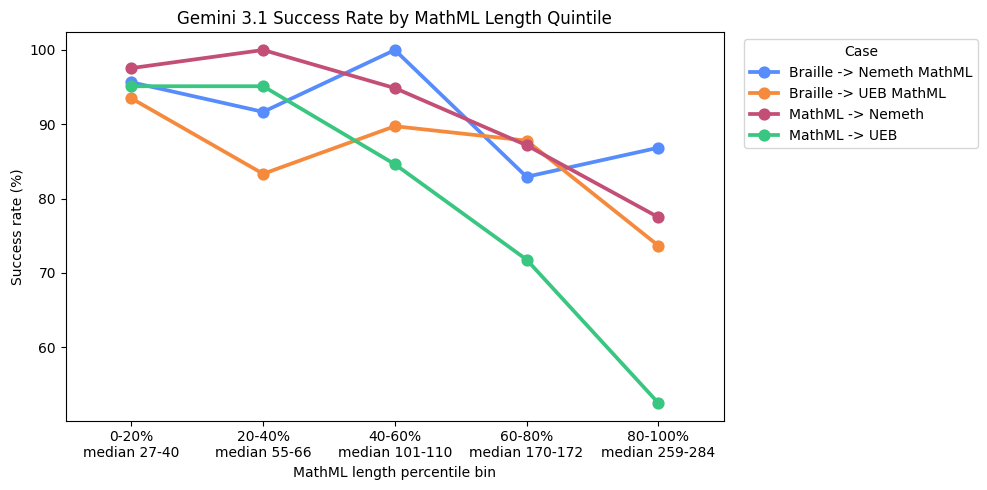

In [6]:
plot_data = quintile_summary.copy()
plot_data["length_bin_label"] = plot_data["length_bin"].map(length_bin_labels["label"])

plt.figure(figsize=(10, 5))
sns.pointplot(
    data=plot_data,
    x="length_bin_label",
    y="success_rate_pct",
    hue="case",
    order=length_bin_labels["label"].tolist(),
    markers="o",
    linestyles="-",
)
plt.title("Gemini 3.1 Success Rate by MathML Length Quintile")
plt.xlabel("MathML length percentile bin")
plt.ylabel("Success rate (%)")
plt.legend(title="Case", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()


## Global Accuracy by Length


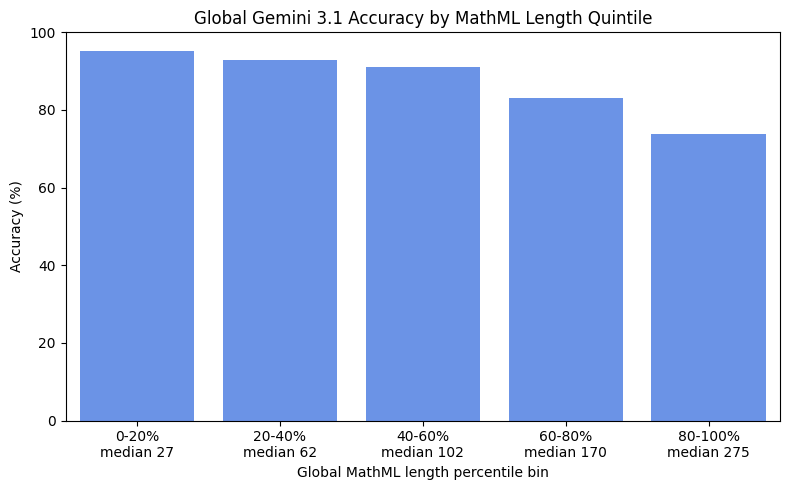

In [7]:
df["global_length_bin"] = pd.qcut(
    df["mathml_length"],
    q=5,
    labels=QUINTILE_LABELS,
    duplicates="drop",
)

global_summary = (
    df.groupby("global_length_bin", observed=True, as_index=False)
    .agg(
        total=("is_success", "size"),
        correct=("is_success", "sum"),
        success_rate=("is_success", "mean"),
        median_mathml_length=("mathml_length", "median"),
    )
)
global_summary["success_rate_pct"] = (global_summary["success_rate"] * 100).round(2)
global_summary = global_summary.sort_values("global_length_bin")
global_summary["length_bin_label"] = global_summary.apply(
    lambda row: f"{row['global_length_bin']}\nmedian {int(row['median_mathml_length'])}",
    axis=1,
)

plt.figure(figsize=(8, 5))
sns.barplot(
    data=global_summary,
    x="length_bin_label",
    y="success_rate_pct",
)
plt.title("Global Gemini 3.1 Accuracy by MathML Length Quintile")
plt.xlabel("Global MathML length percentile bin")
plt.ylabel("Accuracy (%)")
plt.ylim(0, 100)
plt.tight_layout()
plt.show()
